## BST 281 Final Project – Analysis Module 1
This notebook will cover the analyses proposed in module 1, which all utilize the scRNA-seq dataset generated by Bellissimo et al. in Runx1 KO murine LSK hematopoietic progenitors. <br><br>
This first set of analyses will focus on QC, cell annotation, and differential expression across progenitor populations. <br><br>
Per the supplemental methods, raw reads were processed with CellRanger and aligned to mm10. The initial filtering was performed using CellRanger's count function, removing barcodes with fewer than 1000 transcripts. It is this output count matrix that we will be using for the downstream steps.

### Analysis 1
**Objective:** Re-cluster and annotate hematopoietic progenitor populations within the LSK compartment. <br>
**Question:** Does Runx1 loss result in differential abundance of hematopoietic progenitor populations or skewing towards any particular lineage? <br>
**Methods:** Dimensionality reduction and UMAP clustering. <br>
**Output:** UMAP colored by genotype and cell type with bar plots of relative population abundances. 

*1. Set up R environment*

In [351]:
# Load packages
library(Seurat)
library(Matrix)
library(dplyr)
library(ggplot2)
library(tibble)
library(patchwork)
library(stringr)
library(forcats)
library(data.table)

# Set up file paths
data_dir <- "/Users/fionareed/Desktop/BST281/final_project/GSE144482"

# Load data 
count_file <- file.path(data_dir, "gene_by_cell_count_matrix.txt")
cell_anno_file <- file.path(data_dir, "GSE144482_cell_annotation.csv")
gene_anno_file <- file.path(data_dir, "GSE144482_gene_annotation.csv")

*2. Evaluate count matrix*

In [352]:
# First just inspect the structure
readLines(count_file, n = 5)

# Then load the count matrix
counts_raw <- readMM(count_file)

[1] "%%MatrixMarket matrix coordinate integer general"
[2] "31053 14795 60878491"                            
[3] "7 1 11"                                          
[4] "8 1 1"                                           
[5] "10 1 10"

In [353]:
# Confirm the structure of the loaded object
dim(counts_raw)
class(counts_raw)

[1] 31053 14795

[1] "dgTMatrix"
attr(,"package")
[1] "Matrix"

*3. Load cell and gene annotations*

In [354]:
# Cell annotation
cell_anno <- read.csv(
  cell_anno_file,
  header = TRUE,
  row.names = 1,
  check.names = FALSE
)

# Gene annotation
gene_anno <- read.csv(
  gene_anno_file,
  header = TRUE,
  row.names = 1,
  check.names = FALSE
)

# Check loaded objects
dim(cell_anno)
dim(gene_anno)

head(cell_anno)
head(gene_anno)

[1] 14795     7

[1] 31053     2

,barcode,Size_Factor,Total_mRNAs,num_genes_expressed,Dataset,MitoFraction,matched_ctype_refined
,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>
AAACCCAAGCCATGCC-1-1,AAACCCAAGCCATGCC-1-1,4.1061733,70422,6689,Dana_WT,0.05766664,Hba-a2
AAACCCAAGGCTCACC-1-1,AAACCCAAGGCTCACC-1-1,1.1564829,19834,4101,Dana_WT,0.05268730,Ly86
AAACCCACACAATGCT-1-1,AAACCCACACAATGCT-1-1,0.8206283,14074,3855,Dana_WT,0.03360807,Pf4
AAACCCACATGCGTGC-1-1,AAACCCACATGCGTGC-1-1,1.5158358,25997,5462,Dana_WT,0.04754395,CD34
AAACCCATCACTACGA-1-1,AAACCCATCACTACGA-1-1,3.1625149,54238,6845,Dana_WT,0.05191932,Ly86
AAACCCATCAGCAGAG-1-1,AAACCCATCAGCAGAG-1-1,1.6177000,27744,4954,Dana_WT,0.06044550,Ly86


,gene_id,gene_short_name
,<chr>,<chr>
ENSMUSG00000051951,ENSMUSG00000051951,Xkr4
ENSMUSG00000089699,ENSMUSG00000089699,Gm1992
ENSMUSG00000102343,ENSMUSG00000102343,Gm37381
ENSMUSG00000025900,ENSMUSG00000025900,Rp1
ENSMUSG00000025902,ENSMUSG00000025902,Sox17
ENSMUSG00000104328,ENSMUSG00000104328,Gm37323


*3a. Check that dimensions match for the different objects*

In [355]:
nrow(gene_anno)
nrow(cell_anno)
dim(counts_raw)


[1] 31053

[1] 14795

[1] 31053 14795

*4. Identify gene and cell ID columns*

In [356]:
# Inspect objects
colnames(gene_anno)
colnames(cell_anno)

head(gene_anno)
head(cell_anno)


[1] "gene_id"         "gene_short_name"

[1] "barcode"               "Size_Factor"           "Total_mRNAs"          
[4] "num_genes_expressed"   "Dataset"               "MitoFraction"         
[7] "matched_ctype_refined"

,gene_id,gene_short_name
,<chr>,<chr>
ENSMUSG00000051951,ENSMUSG00000051951,Xkr4
ENSMUSG00000089699,ENSMUSG00000089699,Gm1992
ENSMUSG00000102343,ENSMUSG00000102343,Gm37381
ENSMUSG00000025900,ENSMUSG00000025900,Rp1
ENSMUSG00000025902,ENSMUSG00000025902,Sox17
ENSMUSG00000104328,ENSMUSG00000104328,Gm37323


,barcode,Size_Factor,Total_mRNAs,num_genes_expressed,Dataset,MitoFraction,matched_ctype_refined
,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>
AAACCCAAGCCATGCC-1-1,AAACCCAAGCCATGCC-1-1,4.1061733,70422,6689,Dana_WT,0.05766664,Hba-a2
AAACCCAAGGCTCACC-1-1,AAACCCAAGGCTCACC-1-1,1.1564829,19834,4101,Dana_WT,0.05268730,Ly86
AAACCCACACAATGCT-1-1,AAACCCACACAATGCT-1-1,0.8206283,14074,3855,Dana_WT,0.03360807,Pf4
AAACCCACATGCGTGC-1-1,AAACCCACATGCGTGC-1-1,1.5158358,25997,5462,Dana_WT,0.04754395,CD34
AAACCCATCACTACGA-1-1,AAACCCATCACTACGA-1-1,3.1625149,54238,6845,Dana_WT,0.05191932,Ly86
AAACCCATCAGCAGAG-1-1,AAACCCATCAGCAGAG-1-1,1.6177000,27744,4954,Dana_WT,0.06044550,Ly86


*4a. Assign row and column names to the raw count matrix*

In [357]:
gene_col <- "gene_short_name"
cell_col <- "barcode"

gene_names <- as.character(gene_anno[[gene_col]])
gene_names <- make.unique(gene_names)
cell_names <- as.character(cell_anno[[cell_col]])
cell_names <- make.unique(cell_names)

# Assign row and column names to the count matrix
rownames(counts_raw) <- gene_names
colnames(counts_raw) <- cell_names

# Check assigned names
head(rownames(counts_raw))
head(colnames(counts_raw))

[1] "Xkr4"    "Gm1992"  "Gm37381" "Rp1"     "Sox17"   "Gm37323"

[1] "AAACCCAAGCCATGCC-1-1" "AAACCCAAGGCTCACC-1-1" "AAACCCACACAATGCT-1-1"
[4] "AAACCCACATGCGTGC-1-1" "AAACCCATCACTACGA-1-1" "AAACCCATCAGCAGAG-1-1"

*5. Create Seurat object*

In [358]:
runx1 <- CreateSeuratObject(
    counts = counts_raw,
    meta.data = cell_anno,
    project = "GSE144482_Runx1_LSK",
    min.cells = 3, # remove genes detected in < 3 cells
    min.features = 200 # remove cells with < 200 genes detected
)

Warning message:
“Data is of class dgTMatrix. Coercing to dgCMatrix.”


In [359]:
# View Seurat object
runx1

An object of class Seurat 
17859 features across 14795 samples within 1 assay 
Active assay: RNA (17859 features, 0 variable features)
 1 layer present: counts

*6a. QC: Calculate mitochondrial percentages*

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   4.258   4.820   5.595   5.427  76.074 

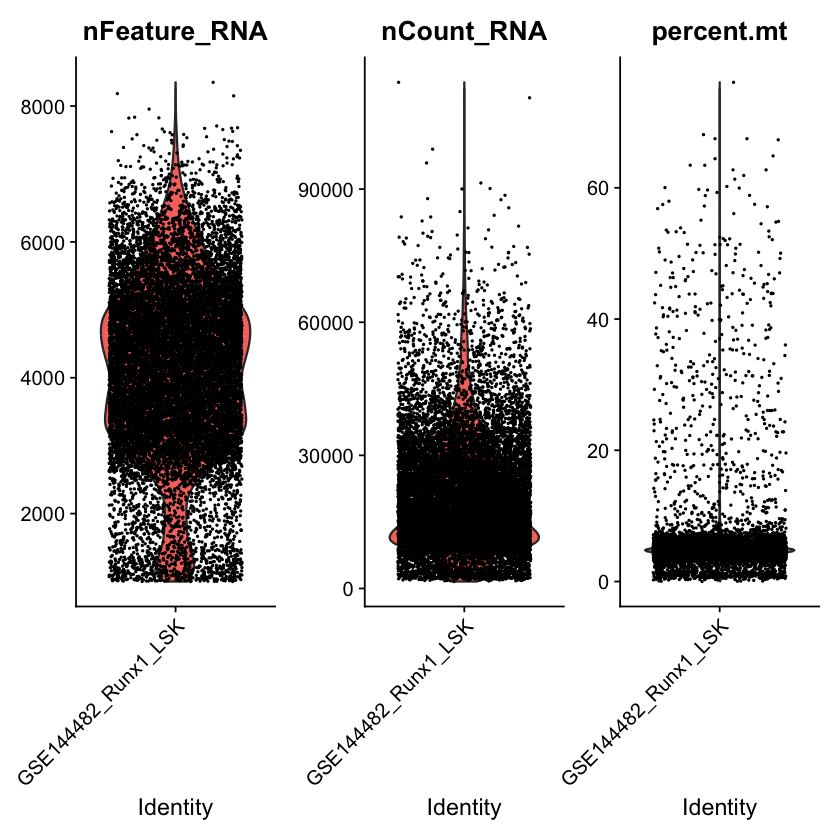

In [360]:
runx1[["percent.mt"]] <- PercentageFeatureSet(runx1, pattern = "^mt-")

VlnPlot(
  runx1,
  features = c("nFeature_RNA", "nCount_RNA", "percent.mt"),
  ncol = 3,
  pt.size = 0.1
)

summary(runx1$percent.mt)

*6b. QC: Inspect relationships between features, and quantiles before filtering*

0%      1%      5%     50%     95%     99%    100% 
1000.00 1090.00 1669.40 4167.00 6125.00 6837.24 8349.00

0%        1%        5%       50%       95%       99%      100% 
  1569.00   2466.94   4598.30  18185.00  44594.30  62443.54 114066.00

0%         1%         5%        50%        95%        99%       100% 
 0.0000000  0.8128303  2.9108849  4.8199809  7.2332559 38.0726459 76.0737108

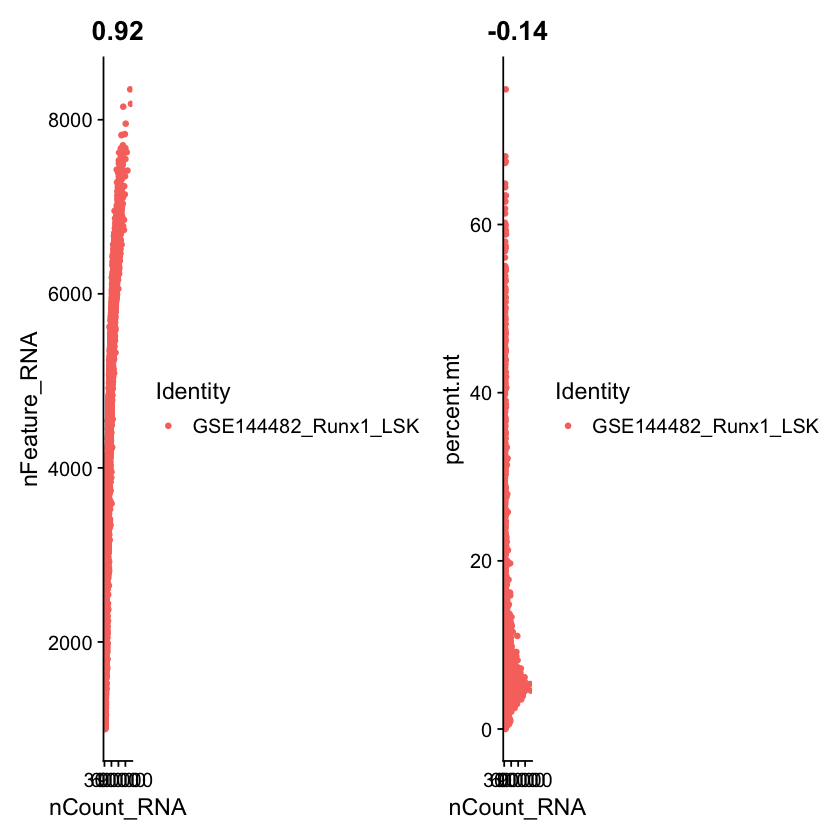

In [361]:
p1 <- FeatureScatter(runx1, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
p2 <- FeatureScatter(runx1, feature1 = "nCount_RNA", feature2 = "percent.mt")

p1 + p2

# QC object for quantile inspection
qc_df <- runx1@meta.data

quantile(qc_df$nFeature_RNA, probs = c(0, 0.01, 0.05, 0.5, 0.95, 0.99, 1))
quantile(qc_df$nCount_RNA, probs = c(0, 0.01, 0.05, 0.5, 0.95, 0.99, 1))
quantile(qc_df$percent.mt, probs = c(0, 0.01, 0.05, 0.5, 0.95, 0.99, 1))


#### *QC Discussion* <br>

**nFeature_RNA:** The distribution looks good overall with a median of 4,167 genes per cell. <br>
**nCount_RNA:** This distribution has a slight rightward skew, with a median of 18,185 UMIs. Probably, the high-count cells are worth filtering out due to concern for doublets. <br>
**percent.mt:** The median is 4.82%, and 95th percentile is 7.23, which suggests that most cells do not have a very high percentage of mitochondrial genes.
**Correlations:** There is 0.92 correlation between nCount_RNA and nFeature_RNA, as expected (cells with more total RNA/UMIs should have more genes). 

*7. Perform filtering based on above thresholds*

In [362]:
runx1_filt <- subset(
  runx1,
  subset = nFeature_RNA > 1000 & # keep cells with > 1000 genes detected
           nFeature_RNA < 7000 & # keep cells with < 7000 genes detected
           nCount_RNA < 65000 & # keep cells with < 65000 UMIs
           percent.mt < 10 # keep cells with < 10% mitochondrial gene expression
)

*8. Perform log-normalization of data.*

In [363]:
runx1_norm <- NormalizeData(
  runx1_filt,
  normalization.method = "LogNormalize",
  scale.factor = 10000
)

Normalizing layer: counts



*9. Identify variable features*

Finding variable features for layer counts



[1] "S100a9" "S100a8" "Camp"   "Ngp"    "Retnlg" "Chil3"  "Lcn2"   "Ltf"   
 [9] "Prss34" "Mcpt8"

When using repel, set xnudge and ynudge to 0 for optimal results

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”


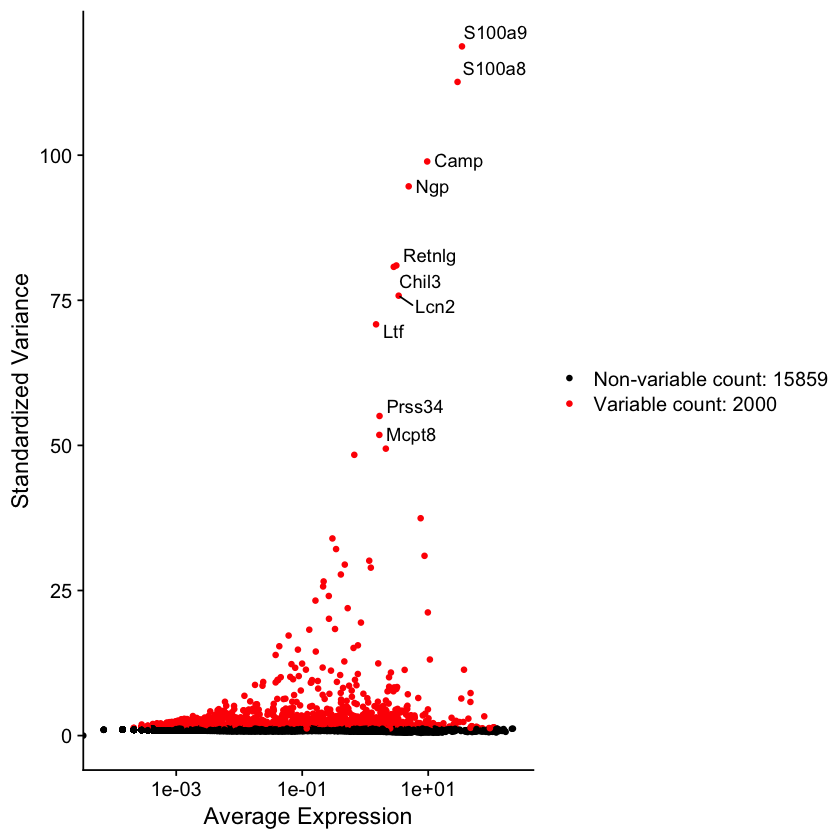

In [364]:
runx1_norm <- FindVariableFeatures(
  runx1_norm,
  selection.method = "vst",
  nfeatures = 2000
)

top10_var <- head(VariableFeatures(runx1_norm), 10)
top10_var

# Plot variable features with labels
p <- VariableFeaturePlot(runx1_norm)
p_labeled <- LabelPoints(
  plot = p,
  points = top10_var,
  repel = TRUE
)
p_labeled


Interesting! The most variable features are highly enriched for inflammatory/granulocytic markers already. 

*9a. Scale variable data*

In [365]:
runx1_scaled <- ScaleData(
  runx1_norm,
  features = VariableFeatures(runx1_norm)
)

Centering and scaling data matrix



*10. Run PCA*

In [366]:
runx1_scaled <- RunPCA(
  runx1_scaled,
  features = VariableFeatures(runx1),
  npcs = 50
)


PC_ 1 
Positive:  Zfpm1, Vamp5, Samd14, Mfsd2b, Nrgn, Aqp1, F2r, Ctla2a, Apoe, Gata1 
	   Car2, Gp5, Sdsl, Slc14a1, Smim1, Plxnc1, Gm15915, Lat, Blvrb, Gfi1b 
	   Treml1, Pbx1, Gnb4, Itga2b, Smim5, Tal1, Hdgf, Abcb4, Meis1, Sept8 
Negative:  Mpo, Ctsg, Tyrobp, Prtn3, Clec12a, Emb, Anxa3, Lcp1, Spi1, Pgam1 
	   Igsf6, Napsa, Plac8, BC035044, Hp, Atp8b4, Elane, Adssl1, Alas1, Tm6sf1 
	   Cd53, Serpinb1a, Hk3, Cd52, Glipr1, Msrb1, Pkm, Cebpd, Cst3, Cebpb 
PC_ 2 
Positive:  Tmsb4x, Cd9, Plek, Pbx1, Ctla2a, Cited2, Lyz2, Itga2b, Rap1b, Rgs18 
	   S100a9, Meis1, Itgb2, Treml1, Retnlg, Cxcr2, Coro1a, Sla, Txnip, Hacd4 
	   S100a6, Mmp9, Cyba, S100a8, Slfn2, Fyb, Unc119, Lrg1, Mcemp1, Pim1 
Negative:  Tuba1b, Npm1, Hsp90aa1, Ran, Hspe1, Hspd1, Dut, Stmn1, Tubb5, Ranbp1 
	   Atp5g1, Tubb4b, C1qbp, Ncl, Ppia, Rrm1, Ptma, Rhd, Spc24, Rps2 
	   Ybx1, Cldn13, Hspa8, Hsp90ab1, Ybx3, Fen1, Cks1b, Gmnn, Top2a, Rpl41 
PC_ 3 
Positive:  Klf1, Tspo2, Car1, Tnfaip2, Atp1b2, Cd24a, Ermap, Ugcg, Blvrb, Gstm

In [367]:
# Create a genotype column because I realized the "genotype" info is in the "Dataset" column
table(runx1$Dataset)

runx1_scaled$genotype <- dplyr::case_when(
  runx1$Dataset == "Dana_WT" ~ "WT",
  runx1$Dataset == "Dana_KO" ~ "Runx1_KO",
  TRUE ~ as.character(runx1$Dataset)
)



Dana_KO Dana_WT 
   7889    6906 

In [368]:

# I also wanted to check and make sure that the author's cell-type annotations made it into the Seurat object
runx1_scaled$author_cell_type <- runx1$matched_ctype_refined
head(runx1_scaled@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,barcode,Size_Factor,Total_mRNAs,num_genes_expressed,Dataset,MitoFraction,matched_ctype_refined,percent.mt,genotype,author_cell_type
,<fct>,<dbl>,<int>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>
AAACCCAAGGCTCACC-1-1,GSE144482_Runx1_LSK,19834,4101,AAACCCAAGGCTCACC-1-1,1.1564829,19834,4101,Dana_WT,0.05268730,Ly86,5.268730,WT,Ly86
AAACCCACACAATGCT-1-1,GSE144482_Runx1_LSK,14074,3855,AAACCCACACAATGCT-1-1,0.8206283,14074,3855,Dana_WT,0.03360807,Pf4,3.360807,WT,Pf4
AAACCCACATGCGTGC-1-1,GSE144482_Runx1_LSK,25996,5461,AAACCCACATGCGTGC-1-1,1.5158358,25997,5462,Dana_WT,0.04754395,CD34,4.754578,WT,CD34
AAACCCATCACTACGA-1-1,GSE144482_Runx1_LSK,54237,6844,AAACCCATCACTACGA-1-1,3.1625149,54238,6845,Dana_WT,0.05191932,Ly86,5.192028,WT,Ly86
AAACCCATCAGCAGAG-1-1,GSE144482_Runx1_LSK,27744,4954,AAACCCATCAGCAGAG-1-1,1.6177000,27744,4954,Dana_WT,0.06044550,Ly86,6.044550,WT,Ly86
AAACCCATCGAGGCAA-1-1,GSE144482_Runx1_LSK,39347,5858,AAACCCATCGAGGCAA-1-1,2.2942490,39347,5858,Dana_WT,0.04338323,CD34,4.338323,WT,CD34


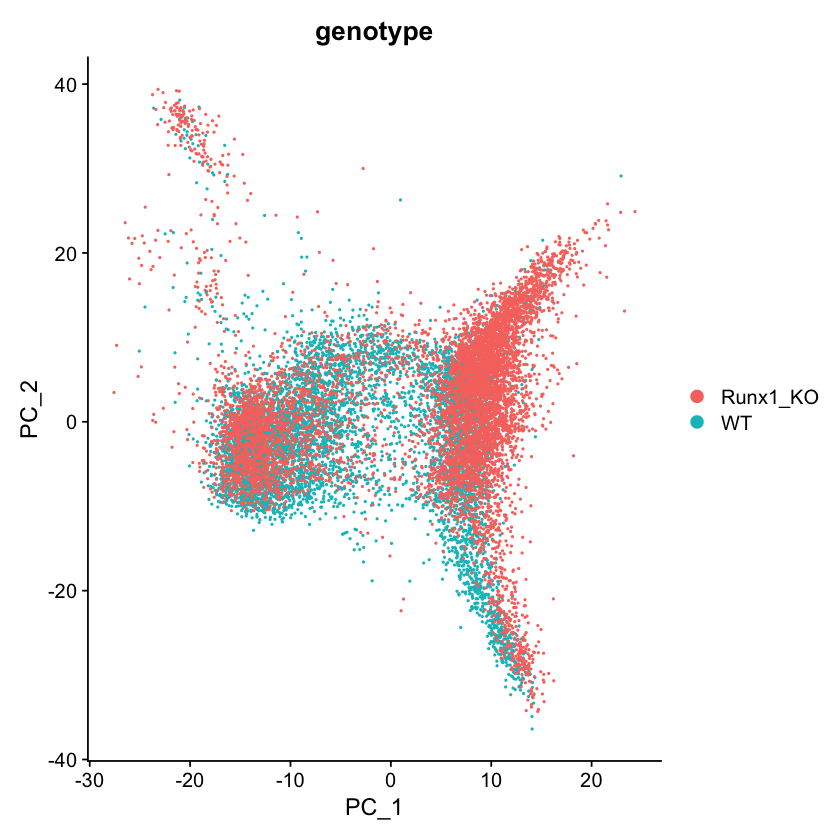

In [369]:
DimPlot(runx1_scaled, reduction = "pca", group.by = "genotype")

*11. Check PCA loadings and select number of PCs*

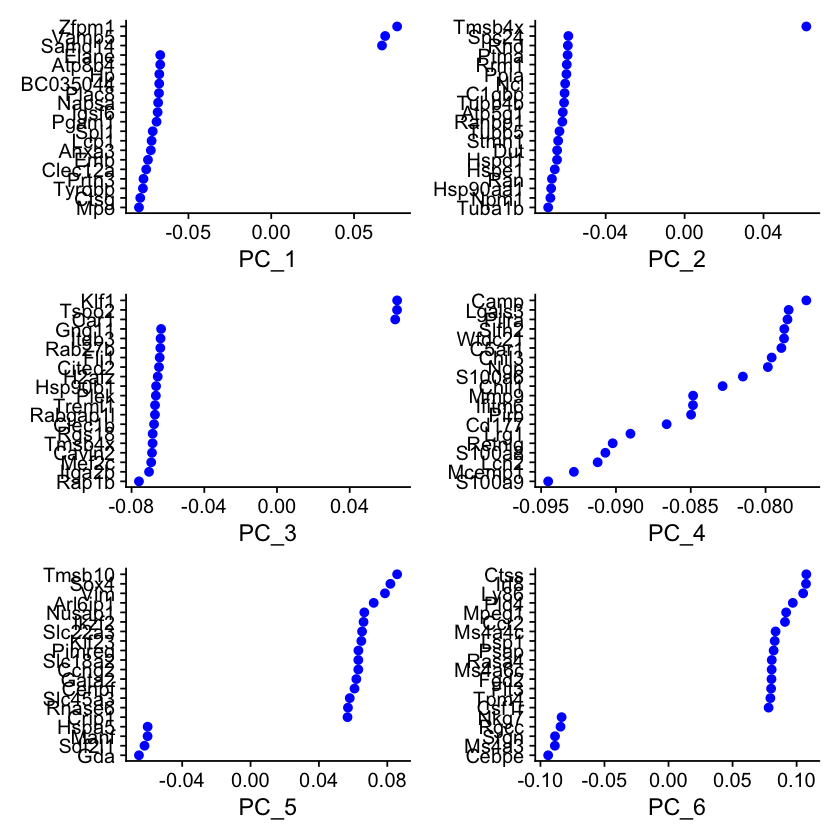

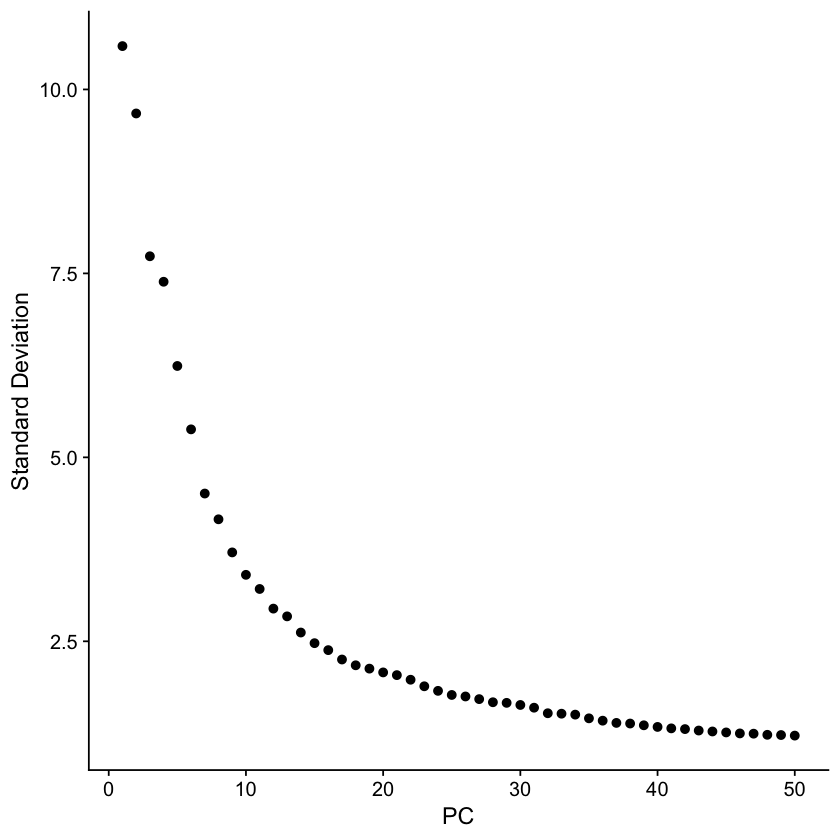

In [370]:
VizDimLoadings(runx1_scaled, dims = 1:6, reduction = "pca", nfeatures = 20)

# Run elbow plot
ElbowPlot(runx1_scaled, ndims = 50)

Based on the elbow plot, there is a sharp drop from 1-10, and then the curve evens out from 15-20. In re-running this several times, I found that using >10 PCs resulted in significant genotype-based skewing, and that reducing the number of PCs used alleviated these effects. 

*12. Build neighbor graph*

In [371]:
pcs_use <- 1:10

runx1_scaled <- FindNeighbors(
  runx1_scaled,
  dims = pcs_use
)

runx1_scaled <- FindClusters(
  runx1_scaled,
  resolution = 0.4 # moderate granularity here to start, can be adjusted
)

table(Idents(runx1_scaled))

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 14137
Number of edges: 433408

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9082
Number of communities: 13
Elapsed time: 0 seconds



   0    1    2    3    4    5    6    7    8    9   10   11   12 
2020 1938 1862 1607 1120 1116 1079  997  755  687  534  285  137 

In [372]:
# Check cluster distribution across genotypes
table(runx1_scaled$seurat_clusters, runx1_scaled$genotype)

prop.table(
  table(runx1_scaled$seurat_clusters, runx1_scaled$genotype),
  margin = 1
)

    
     Runx1_KO   WT
  0       985 1035
  1       415 1523
  2      1464  398
  3      1525   82
  4       720  400
  5       445  671
  6        48 1031
  7       766  231
  8       227  528
  9       332  355
  10       32  502
  11      218   67
  12       54   83

    
       Runx1_KO         WT
  0  0.48762376 0.51237624
  1  0.21413829 0.78586171
  2  0.78625134 0.21374866
  3  0.94897324 0.05102676
  4  0.64285714 0.35714286
  5  0.39874552 0.60125448
  6  0.04448563 0.95551437
  7  0.76830491 0.23169509
  8  0.30066225 0.69933775
  9  0.48326055 0.51673945
  10 0.05992509 0.94007491
  11 0.76491228 0.23508772
  12 0.39416058 0.60583942

There appear to be pretty strong genotype-specific effects here, which make me pretty nervous, as I was hoping to see strong biological signal here–but this is stronger than I was anticipating already. It's very possible that this is a sample effect, but sample/batch wasn't included in the author metadata. We soldier on. 

*13. Run UMAP*

In [373]:
set.seed(123) # for reproducibility

runx1_scaled <- RunUMAP(
    object = runx1_scaled, 
    dims = pcs_use,
    reduction = "pca"
    )

21:04:11 UMAP embedding parameters a = 0.9922 b = 1.112

21:04:11 Read 14137 rows and found 10 numeric columns

21:04:11 Using Annoy for neighbor search, n_neighbors = 30

21:04:11 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

21:04:12 Writing NN index file to temp file /var/folders/vs/hgkq5zc90fgd2cjtflhhvlr80000gn/T//RtmpCvigkM/file9f7e464dc950

21:04:12 Searching Annoy index using 1 thread, search_k = 3000

21:04:14 Annoy recall = 100%

21:04:15 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

21:04:16 Initializing from normalized Laplacian + noise (using RSpectra)

21:04:16 Commencing optimization for 200 epochs, with 543496 positive edges

21:04:16 Using rng type: pcg

21:04:20 Optimization finished



*14. Plot various UMAPS:*<br>
1. De novo clusters from our analysis <br>
2. Annoted with genotypes <br>
3. Side-by-side comparison of genotype composition in various clusters <br>
4. Original author annotations.

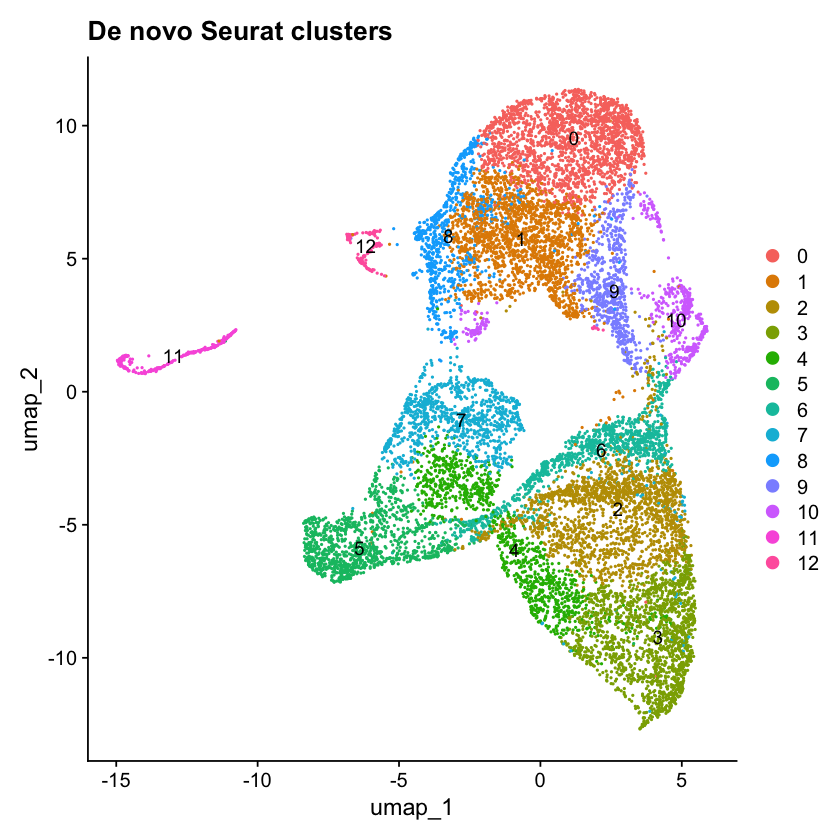

In [374]:
DimPlot(runx1_scaled, reduction = "umap", label = TRUE) +
  ggtitle("De novo Seurat clusters")

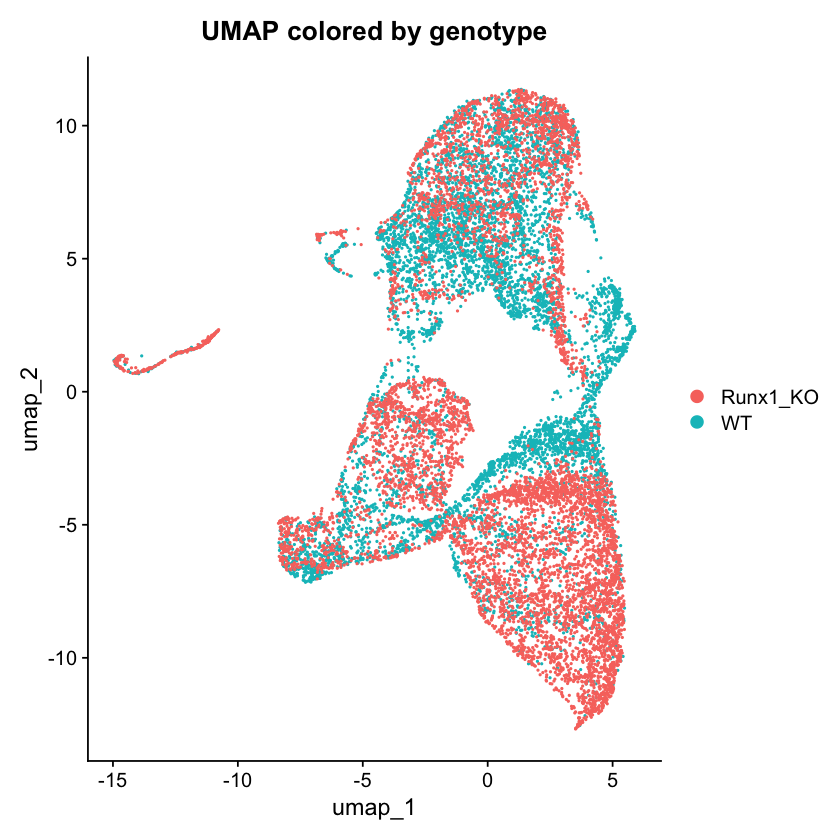

In [375]:
# Annotate UMAP clusters based on genotype 
DimPlot(
  runx1_scaled,
  reduction = "umap",
  group.by = "genotype"
) +
  ggtitle("UMAP colored by genotype")

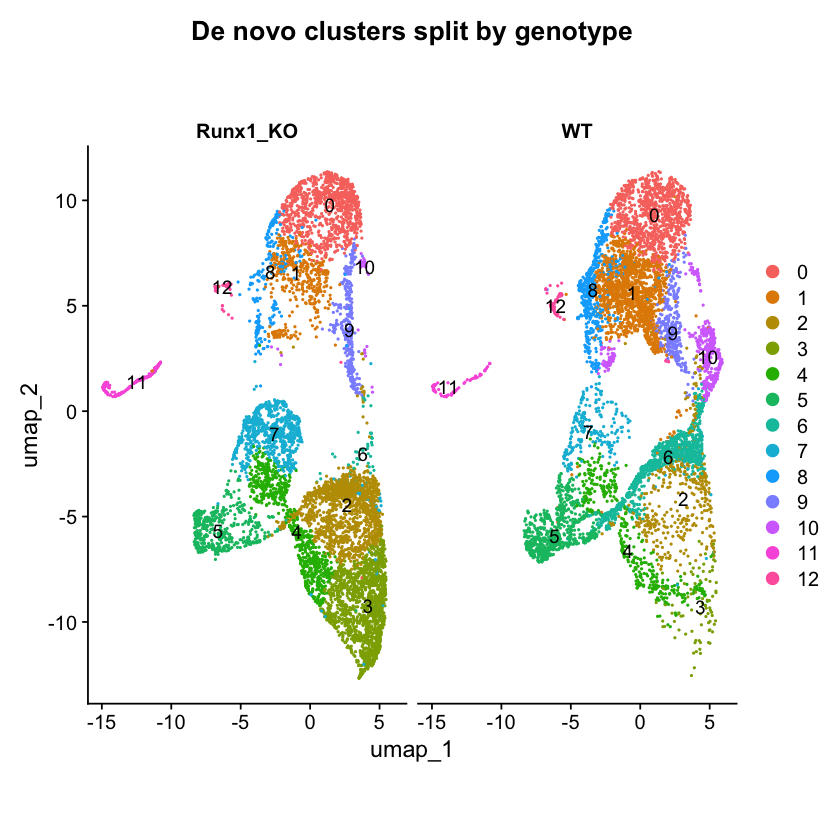

In [376]:
# Look at genotype within the de novo Seurat clusters
DimPlot(
  runx1_scaled,
  reduction = "umap",
  group.by = "seurat_clusters",
  split.by = "genotype",
  label = TRUE
) +
  ggtitle("De novo clusters split by genotype") + 
  theme(aspect.ratio = 1.75)

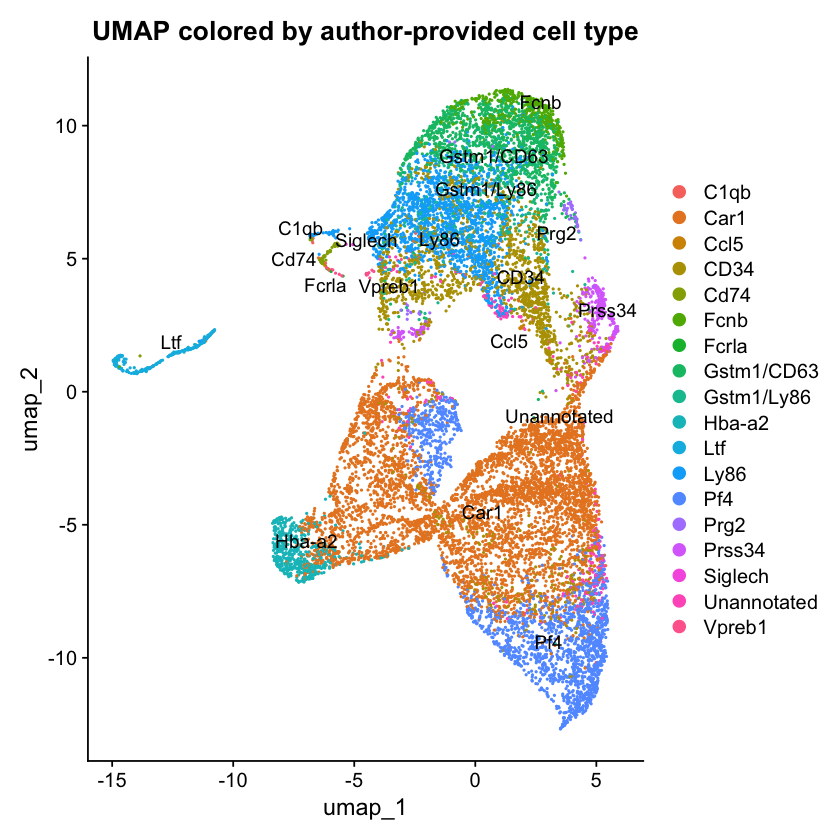

In [377]:
# UMAP colored by author's original cell type annotations
DimPlot(
  runx1_scaled,
  reduction = "umap",
  group.by = "author_cell_type",
  label = TRUE,
  repel = TRUE
) +
  ggtitle("UMAP colored by author-provided cell type")

*15. Compare author annotations to the clusters that we re-defined in our analysis*

In [378]:
cluster_author_table <- table(
  SeuratCluster = runx1_scaled$seurat_clusters,
  AuthorCellType = runx1_scaled$author_cell_type
)

cluster_author_table

             AuthorCellType
SeuratCluster C1qb Car1 Ccl5 CD34 Cd74 Fcnb Fcrla Gstm1/CD63 Gstm1/Ly86 Hba-a2
           0     0    0    0   82    0  475     0       1104        156      0
           1     3   23    0  452    0    0     2          1        163      0
           2     0 1672    0  108    0    0     0          1          0      3
           3     1  207    0   72    0    0     0          0          0      2
           4     0  797    0   64    0    0     0          0          0      0
           5     0  613    0    0    0    0     0          1          0    502
           6     0 1056    0    9    0    0     0          0          0      0
           7     0  565    0   34    0    0     0          0          1      2
           8     0    5    0  213    0    4     1         79         60      0
           9     1    1    2  554    0    1     0         58         39      0
           10    0   44    0   92    0    0     0         18         10      0
           11    1    1 

Overall, our de novo Seurat-defined clusters map pretty strongly onto the authors labeling scheme and recapitulate their analysis, which is reassuring that our highly genotype-based skewing is reflective of real biology and not sample or batch effect.


*16. Rename clusters to actual cell types based on literature* <br><br>
The authors' annotations are based on those from Giladi et al. "Single-cell characterization of haematopoietic progenitors and their trajectories in homeostasis and perturbed haematopoiesis (2018) [https://pubmed.ncbi.nlm.nih.gov/29915358/]. In order to derive more biological meaning from our labels, I will rename the author clusters based on these cell identities and use this to define the dominant identitiy in each of our de novo Seurat-defined clusters. . 

In [379]:
# Remap author annotations according to Giladi et al. reference dataset
author_to_Giladi <- c(
  "C1qb" = "Macrophages",
  "Car1" = "Megakaryocyte-erythroid progenitors",
  "Ccl5" = "Lymphocytes",
  "CD34" = "HSCs",
  "Cd74" = "Dendritic cells",
  "Fcnb" = "Neutrophils",
  "Fcrla" = "B cells",
  "Gstm1/CD63" = "Neutrophil progenitors",
  "Gstm1/Ly86" = "Granulocyte-monocyte progenitors",
  "Hba-a2" = "Erythrocytes",
  "Ltf" = "Neutrophils",
  "Ly86" = "Monocytes",
  "Pf4" = "Megakaryocytes",
  "Prg2" = "Eosinophils",
  "Prss34" = "Basophils",
  "Siglech" = "Plasmacytoid dendritic cells",
  "Vpreb1" = "B cells"
)


In [380]:
# Create new annotation columns
mapped_author_Giladi <- author_to_Giladi[as.character(runx1_scaled$author_cell_type)]

# Remove names so Seurat assigns by cell order
runx1_scaled$author_Giladi <- unname(mapped_author_Giladi)

In [381]:
# Create Seurat cluster x Giladi annotation table for comparison
cluster_author_Giladi_table <- table(
  SeuratCluster = runx1_scaled$seurat_clusters,
  AuthorGiladi = runx1_scaled$author_Giladi
)

# Convert to proportions
cluster_author_Giladi_prop <- prop.table(
  cluster_author_Giladi_table,
  margin = 1
)

cluster_author_Giladi_prop

             AuthorGiladi
SeuratCluster      B cells    Basophils Dendritic cells  Eosinophils
           0  0.0000000000 0.0000000000    0.0000000000 0.0029702970
           1  0.0037313433 0.0010660981    0.0000000000 0.0010660981
           2  0.0000000000 0.0016492578    0.0000000000 0.0000000000
           3  0.0000000000 0.0006531679    0.0000000000 0.0000000000
           4  0.0000000000 0.0000000000    0.0000000000 0.0000000000
           5  0.0000000000 0.0000000000    0.0000000000 0.0000000000
           6  0.0000000000 0.0028089888    0.0000000000 0.0000000000
           7  0.0000000000 0.0000000000    0.0000000000 0.0000000000
           8  0.0161943320 0.0337381916    0.0000000000 0.0026990553
           9  0.0000000000 0.0014792899    0.0000000000 0.0000000000
           10 0.0000000000 0.5838264300    0.0000000000 0.0927021696
           11 0.0000000000 0.0000000000    0.0035087719 0.0000000000
           12 0.0888888889 0.0000000000    0.4518518519 0.0000000000
        

A number of our Seurat-defined clusters here tend to have MK/MK-E overlap identities. This is probably because there is strong biological signal within these clusters due to Runx1 loss significantly altering the trajectory of megakaryocyte fate commitment and differentiation. To clean this up, I will manually re-annotate our Seurat clusters based on the predominating cell identities from Giladi. 

In [382]:
# Manually define clusters based on composition
cluster_compressed <- c(
    "0" = "Neutrophils",
    "1" = "Myeloid-biased progenitors",
    "2" = "Megakaryocyte-erythroid progenitors",
    "3" = "Megakaryocytes",
    "4" = "Megakaryocyte progenitors",
    "5" = "Erythrocytes",
    "6" = "Megakaryocyte-erythroid progenitors",
    "7" = "Erythroid progenitors",
    "8" = "Granulocyte-monocyte progenitors",
    "9" = "Hematopoietic stem cells",
    "10" = "Basophils",
    "11" = "Neutrophils",
    "12" = "Dendritic cells"
)

runx1_scaled$manual_celltype <- unname(
  cluster_compressed[as.character(runx1_scaled$seurat_clusters)]
)
table(runx1_scaled$seurat_clusters, runx1_scaled$manual_celltype)

    
     Basophils Dendritic cells Erythrocytes Erythroid progenitors
  0          0               0            0                     0
  1          0               0            0                     0
  2          0               0            0                     0
  3          0               0            0                     0
  4          0               0            0                     0
  5          0               0         1116                     0
  6          0               0            0                     0
  7          0               0            0                   997
  8          0               0            0                     0
  9          0               0            0                     0
  10       534               0            0                     0
  11         0               0            0                     0
  12         0             137            0                     0
    
     Granulocyte-monocyte progenitors Hematopoietic stem cells
  0

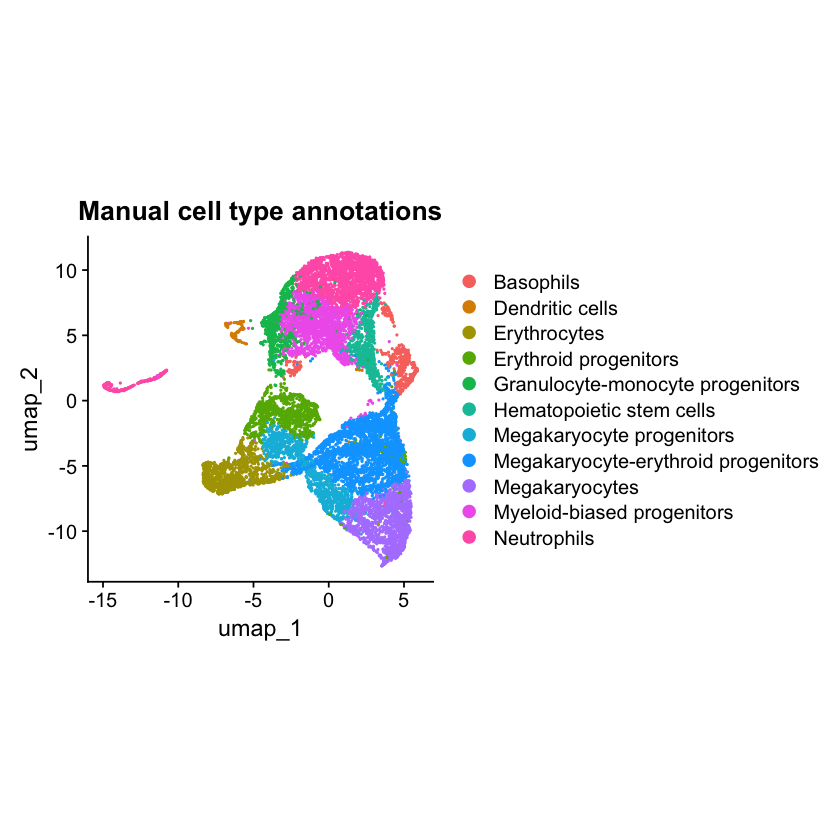

In [383]:
# Plot manual cell annotations
DimPlot(
  runx1_scaled,
  reduction = "umap",
  group.by = "manual_celltype",
  repel = TRUE
) +
  ggtitle("Manual cell type annotations") +
  theme(aspect.ratio = 1)

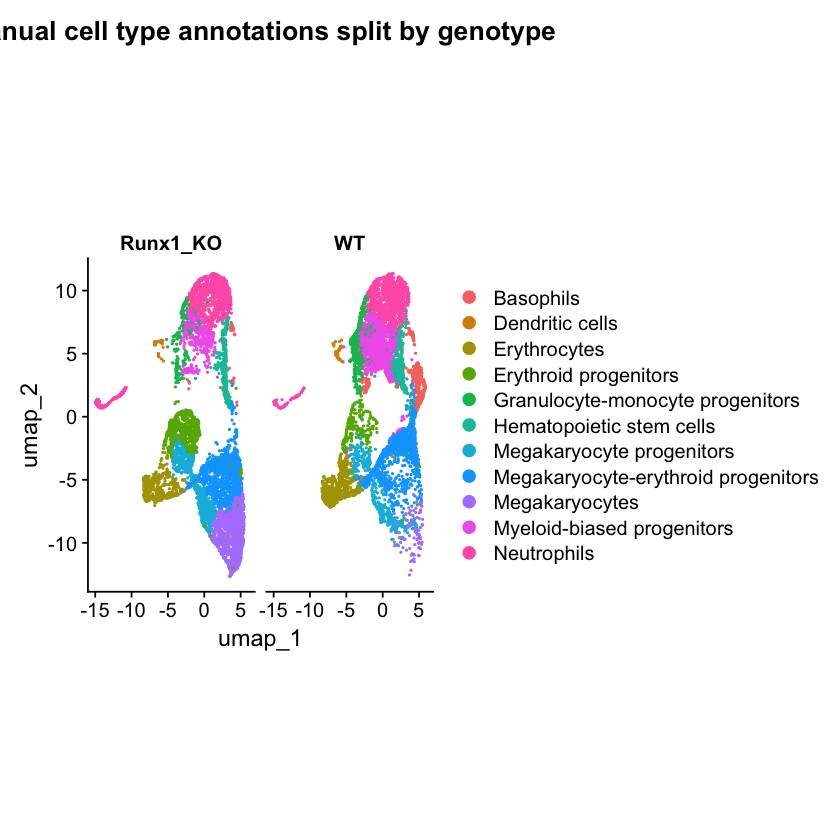

In [384]:
# Plot manual cell type annotations by genotype
DimPlot(
  runx1_scaled,
  reduction = "umap",
  group.by = "manual_celltype",
  split.by = "genotype",
  repel = TRUE
) +
  ggtitle("Manual cell type annotations split by genotype") +
  theme(aspect.ratio = 2)

Reassuringly, this UMAP shows sensible relationships between early vs late progenitor compartments, which is reassuring relative to the rigor of our analysis.

*17. Determine relative abundances of cell populations*

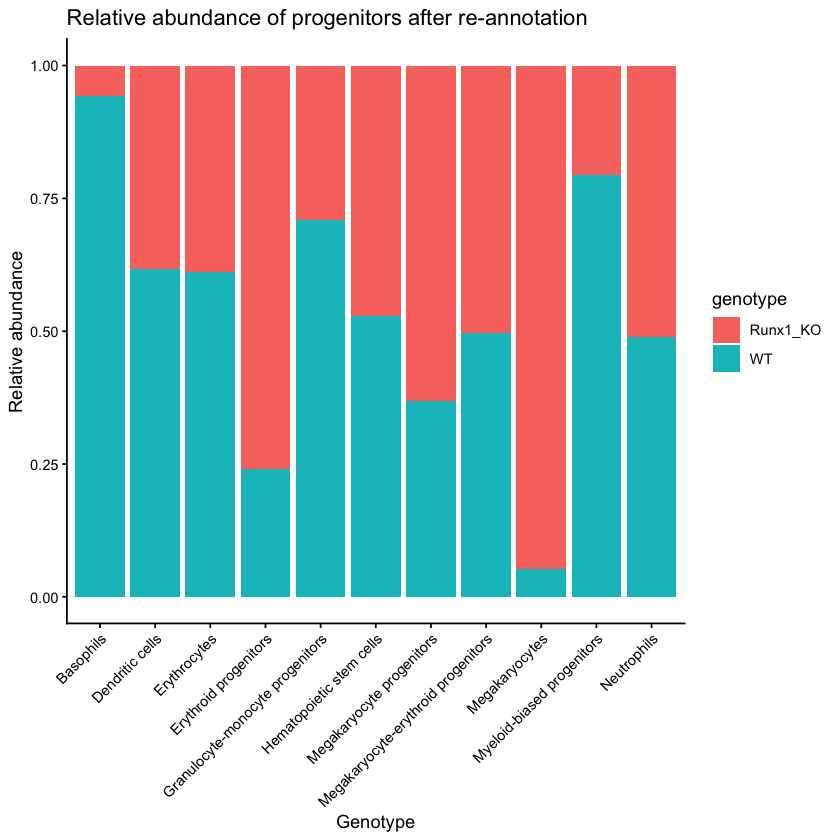

In [385]:
abundances <- runx1_scaled@meta.data %>%
count(genotype, manual_celltype, name = "n_cells") %>%
    group_by(genotype) %>%
    mutate(
        total_cells = sum(n_cells),
        prop = n_cells / total_cells    
    ) %>%
    ungroup()

ggplot(abundances, aes(x = manual_celltype, y = prop, fill = genotype)) +
geom_col(position = "fill") +
  theme_classic() +
  xlab("Genotype") +
  ylab("Relative abundance") +
  ggtitle("Relative abundance of progenitors after re-annotation") +
   theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

*18. Faceted abundance plots for each cell type*

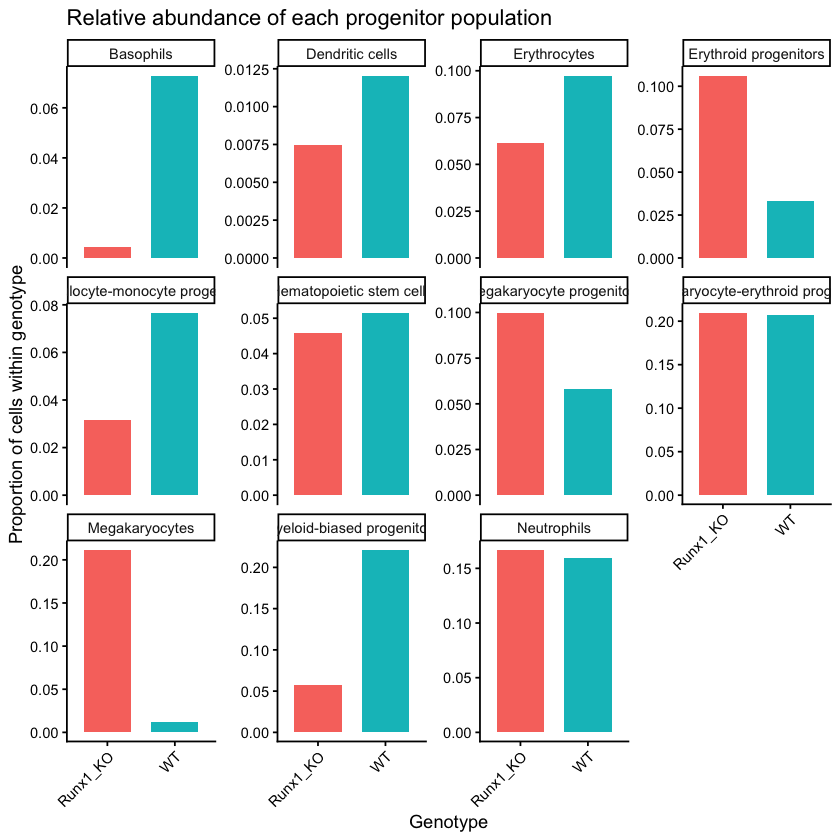

In [386]:
ggplot(abundances, aes(x = genotype, y = prop, fill = genotype)) +
  geom_col(width = 0.7) +
  facet_wrap(~ manual_celltype, scales = "free_y") +
  ylab("Proportion of cells within genotype") +
  xlab("Genotype") +
  theme_classic() +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 45, hjust = 1)
  ) +
  ggtitle("Relative abundance of each progenitor population")

*19. Progenitor abundance within genotypes*

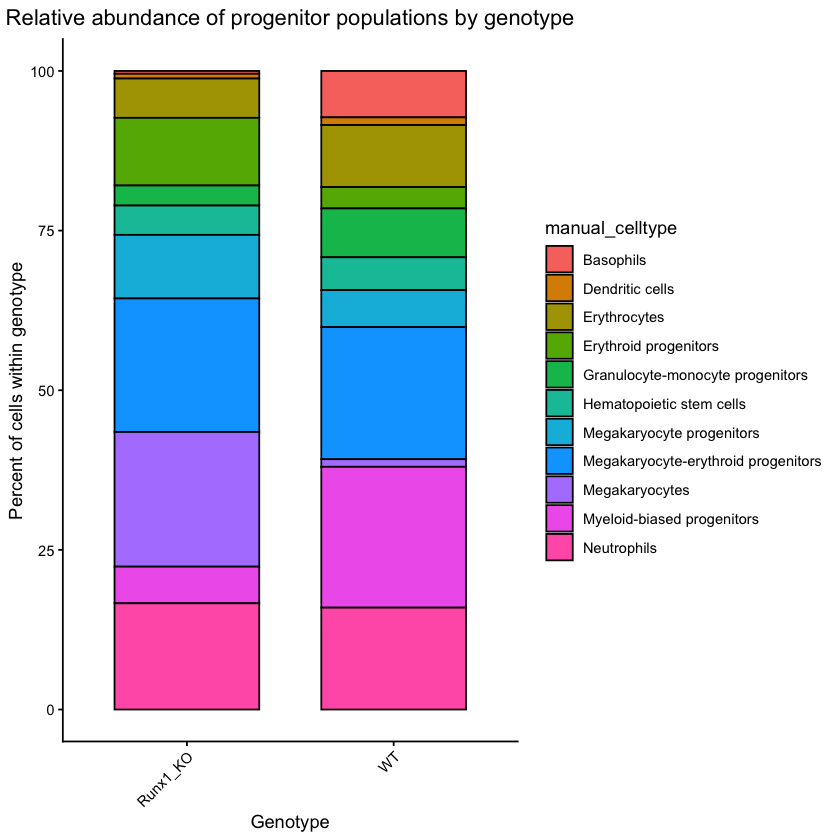

In [387]:
# Calculate relative abundance of each compressed progenitor population within each genotype
manual_abundance <- runx1_scaled@meta.data %>%
  filter(!is.na(manual_celltype)) %>%
  count(genotype, manual_celltype, name = "n_cells") %>%
  group_by(genotype) %>%
  mutate(
    total_cells = sum(n_cells),
    prop = n_cells / total_cells,
    percent = prop * 100
  ) %>%
  ungroup()

ggplot(
  manual_abundance,
  aes(x = genotype, y = percent, fill = manual_celltype)
) +
  geom_col(color = "black", width = 0.7) +
  theme_classic() +
  xlab("Genotype") +
  ylab("Percent of cells within genotype") +
  ggtitle("Relative abundance of progenitor populations by genotype") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(hjust = 0.5)
  )

The finding of significant basophil depletion in Runx1 KO is something that the authors also found despite a slightly different clustering method, which is again reassuring. 

*Final: Save Seurat object for downstream analyses*

In [388]:
saveRDS(runx1, file = file.path(data_dir, "GSE144482_Runx1_LSK_reclustered_FR.rds"))

### Analysis 2
**Objective:** Perform differential expression analysis across different hematopoietic progenitor subsets.<br>
**Question:** Is there differential expression in Runx1 KO vs WT progeintors, and what are the top hits?<br>
**Methods:** Perform differential expression testing with edgeR and comparing counts per mouse per cell type of each genotype to best leverage biological replicates. <br>
**Output:** 1) Volcano plots of top differentially expressed genes in each lineage, with specific annotation of inflammatory/innate immune genes; 2) Heatmap comparing differential expression of these genes in Runx1 KO vs WT mice.

*1. Set up R environment*

In [389]:
library(Seurat)
library(Matrix)
library(dplyr)
library(tidyr)
library(tibble)
library(edgeR)
library(ggplot2)
library(ggrepel)
library(pheatmap)
library(stringr)

*2. Confirm metadata columns in Seurat object (optional: reload saved Seurat object from Analysis 1)*

In [390]:
colnames(runx1_scaled@meta.data) 

genotype_col <- "genotype"
celltype_col <- "manual_celltype"

[1] "orig.ident"            "nCount_RNA"            "nFeature_RNA"         
 [4] "barcode"               "Size_Factor"           "Total_mRNAs"          
 [7] "num_genes_expressed"   "Dataset"               "MitoFraction"         
[10] "matched_ctype_refined" "percent.mt"            "genotype"             
[13] "author_cell_type"      "RNA_snn_res.0.4"       "seurat_clusters"      
[16] "author_Giladi"         "manual_celltype"

*3. Create genotype-celltype pseudobulk counts*

In [391]:
counts <- GetAssayData(runx1_scaled, assay = "RNA", layer = "counts")
meta <- runx1_scaled@meta.data
meta <- meta[colnames(counts), , drop = FALSE]

# Pseudobulked version for edgeR
meta_pb <- meta %>%
    rownames_to_column("cell_id") %>%
    select(cell_id, genotype, manual_celltype) %>%
    mutate(pseudobulk_id = paste(genotype, manual_celltype, sep = "_"))

counts_use <- counts[, meta_pb$cell_id]

grouping <- factor(meta_pb$pseudobulk_id)
group_mat <- Matrix::sparse.model.matrix(~ 0 + grouping)

pb_counts <- counts_use %*% group_mat
colnames(pb_counts) <- levels(grouping)
colnames(pb_counts) <- gsub("^grouping", "", colnames(pb_counts))

dim(pb_counts)
colnames(pb_counts) # Check to confirm all cell types are represented in the final pseudobulk

[1] 17859    22

[1] "Runx1_KO_Basophils"                          
 [2] "Runx1_KO_Dendritic cells"                    
 [3] "Runx1_KO_Erythrocytes"                       
 [4] "Runx1_KO_Erythroid progenitors"              
 [5] "Runx1_KO_Granulocyte-monocyte progenitors"   
 [6] "Runx1_KO_Hematopoietic stem cells"           
 [7] "Runx1_KO_Megakaryocyte progenitors"          
 [8] "Runx1_KO_Megakaryocyte-erythroid progenitors"
 [9] "Runx1_KO_Megakaryocytes"                     
[10] "Runx1_KO_Myeloid-biased progenitors"         
[11] "Runx1_KO_Neutrophils"                        
[12] "WT_Basophils"                                
[13] "WT_Dendritic cells"                          
[14] "WT_Erythrocytes"                             
[15] "WT_Erythroid progenitors"                    
[16] "WT_Granulocyte-monocyte progenitors"         
[17] "WT_Hematopoietic stem cells"                 
[18] "WT_Megakaryocyte progenitors"                
[19] "WT_Megakaryocyte-erythroid progenitors"      
[20] "WT_Megakaryocytes"                           
[21] "WT_Myeloid-biased progenitors"               
[22] "WT_Neutrophils"

*4. Define the edgeR function for genotype comparison within one cell type at a time* <br><br>

A note here: this is the point in my analysis at which I realized that in fact the authors had used 1 mouse for each genotype and there were no biological replicates or multiple pooled samples with which to run the necessary edgeR tests. This is obviously a major flaw in the dataset we've chosen. edgeR allows you to manually set a dispersion level based on biological coefficient of variation. For this one replicate dataset, I will set a high/conservative level of variation around 0.25 and run edgeR on this, understanding that what it reports is less likely to represent robust biological meaning in the absence of multiple replicates.

In [392]:
run_edgeR_dispersion <- function(celltype_name, pb_counts, bcv = 0.25, wt_label = "WT", ko_label = "Runx1_KO") {
  
  message("Running edgeR for: ", celltype_name)

  wt_col <- paste(wt_label, celltype_name, sep = "_")
  ko_col <- paste(ko_label, celltype_name, sep = "_")
  
 counts_ct <- pb_counts[, c(wt_col, ko_col), drop = FALSE]
  
  # Remove genes with zero counts in both groups
  keep_nonzero <- rowSums(counts_ct) > 0
  counts_ct <- counts_ct[keep_nonzero, , drop = FALSE]
  
  group <- factor(c(wt_label, ko_label), levels = c(wt_label, ko_label))
  
  dge <- DGEList(counts = counts_ct, group = group)
  dge <- calcNormFactors(dge)
  
  design <- model.matrix(~ group)
  colnames(design) <- c("Intercept", "KO_vs_WT")
  
  # Fixed dispersion
  dispersion <- bcv^2
  
  # Exact test can be used with manually supplied dispersion
  et <- exactTest(
    dge,
    pair = c(wt_label, ko_label),
    dispersion = dispersion
  )
  
  res <- topTags(et, n = Inf)$table %>%
    rownames_to_column("gene") %>%
    mutate(
      celltype = celltype_name,
      bcv = bcv,
      dispersion = dispersion,
      FDR = p.adjust(PValue, method = "BH")
    )
  
  return(res)
}


*5. Run edgeR across all cell types*

In [393]:
# Define list of cell types to test
celltypes_to_test <- sort(unique(runx1_scaled$manual_celltype))

# Run edgeR for each cell type and store results in a list
dge_results_list <- lapply(
    celltypes_to_test, 
    run_edgeR_dispersion,
    pb_counts = pb_counts,
    bcv = 0.25
)

Running edgeR for: Basophils

Running edgeR for: Dendritic cells

Running edgeR for: Erythrocytes

Running edgeR for: Erythroid progenitors

Running edgeR for: Granulocyte-monocyte progenitors

Running edgeR for: Hematopoietic stem cells

Running edgeR for: Megakaryocyte progenitors

Running edgeR for: Megakaryocyte-erythroid progenitors

Running edgeR for: Megakaryocytes

Running edgeR for: Myeloid-biased progenitors

Running edgeR for: Neutrophils



In [394]:
# Inspect the edgeR results
names(dge_results_list) <- celltypes_to_test
dge_results <- bind_rows(dge_results_list)

# Sanity check of output
dge_results_check <- dge_results %>%
    group_by(celltype) %>%
    summarize(
        n_sig = sum(FDR < 0.05),
        n_total = n(),
        prop_sig = n_sig / n_total, 
        n_abs_logFC_gt_1 = sum(abs(logFC) > 1, na.rm = TRUE),
        top_up = gene[which.max(logFC)],
        top_down = gene[which.min(logFC)],
    )
dge_results_check

celltype,n_sig,n_total,prop_sig,n_abs_logFC_gt_1,top_up,top_down
<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
Basophils,65,14452,0.0044976474,5644,Clec1b,Gzmb
Dendritic cells,305,13447,0.0226816390,4938,Saa3,Jchain
Erythrocytes,139,15465,0.0089880375,3533,Nrg3,Gml2
Erythroid progenitors,88,15367,0.0057265569,3933,Gm6569,Gm10419
Granulocyte-monocyte progenitors,128,15454,0.0082826453,3859,Thbs1,Scin
Hematopoietic stem cells,66,14625,0.0045128205,3430,Nrg3,Trbc1
Megakaryocyte progenitors,158,15539,0.0101679645,3533,Lilrb4a,Kcnc1
Megakaryocyte-erythroid progenitors,214,16088,0.0133018399,3740,6030468B19Rik,Kcnc1
Megakaryocytes,3,15471,0.0001939112,4792,Tep1,Gm33104


Despite the issue of replicates within this dataset, setting a relatively conservative bcv threshold at 0.25 results in a sane-looking output of differential expression, where each cell type has tens to hundreds of differentially expressed genes between WT and Runx1 KO out of tens of thousands of total genes. The proportions are somewhat similar. We soldier on.

*6. Annotate genes as immune/inflammatory*

In [396]:
# This isn't going to be every single gene but it's a good start
inflammatory_genes <- c(
  # TLR / innate sensing
  "Tlr1", "Tlr2", "Tlr4", "Tlr6", "Tlr7", "Tlr8", "Tlr9",
  "Myd88", "Ticam1", "Traf6", "Irak1", "Irak2", "Irak3", "Irak4",
  
  # NF-kB / inflammatory response
  "Nfkb1", "Nfkb2", "Rela", "Rel", "Relb", "Nfkbia", "Nfkbie",
  "Tnfaip3", "Zc3h12a",
  
  # Cytokines / chemokines
  "Il1b", "Il6", "Il18", "Tnf",
  "Ccl2", "Ccl3", "Ccl4", "Ccl5", "Cxcl1", "Cxcl2", "Cxcl10",
  
  # Interferon stimulated genes
  "Ifitm1", "Ifitm2", "Ifitm3",
  "Irf1", "Irf7", "Irf8", "Isg15", "Ifit1", "Ifit2", "Ifit3",
  "Oas1a", "Oas2", "Mx1", "Stat1", "Stat2",
  
  # Myeloid inflammatory / neutrophil-associated
  "S100a8", "S100a9", "Lcn2", "Mpo", "Elane", "Prtn3", "Ctsg",
  "Fcnb", "Lyz2",
  
  # Antigen presentation / MHC-II
  "Cd74", "H2-Aa", "H2-Ab1", "H2-Eb1",
  
  # Complement / macrophage-like
  "C1qa", "C1qb", "C1qc"
)

# Add flags to DGE results
dge_results <- dge_results %>%
    mutate(
        is_inflammatory = gene %in% inflammatory_genes
    )

*7. Define a volcano plotting function*

In [ ]:
plot_volcano <- function(dge_df, celltype_name) {

# First you probably want to label the significant genes that are FDR < 0.05 and logFC > 0.5 or 1
# I'd create a label something like above, or a new column that is significant = TRUE/FALSE based on those thresholds as opposed to just filtering out non-significant genes
# Then I would arrange the dataframe in descending order of FDR to get the most significantly differentially expressed genes
# You can use head() to take a look at say the top 25 most significant genes or something just to get an idea
# The usual code for volcano plot is something like this: ggplot(dge_df, aes(x = logFC, y = -log10(FDR))
# I would make two volcano plots for each cell type: 1 with significant genes labeled 1 and 1 with inflammatory genes colored/highlighted 
# Also as part of this it can be nice to have a top hits table for each cell type that is like the top 25 most sig genes with name, logFC, logCPM, PValue, FDR
}

*8. Make volcano plots for all cell types*

In [ ]:
# Just run your volcano plot function here
# Something like plot_volcano(dge_results, celltype_name = "Neutrophils")
# Do it for every cell type and save the plots somewhere

*9. Make a heatmap to visualize inflammatory gene expression across genotypes and cell types.*

In [ ]:
# Ideally for this you will get some kind of matrix showing the logFC of the inflammatory gene list we defined above in each cell type
# Might be easiest to make a new dataframe that has one row per gene and one column per cell type with the logFC values, then you can make a heatmap of just the inflammatory genes across cell types or something like that
# I would include non-significantly differentially expressed genes in the heatmap too just to see the overall pattern of expression of these genes across cell types, not just the significant ones
# A good function for this is pheatmap() from the pheatmap package which I loaded above, you can look up the documentation